COE 311K Final Project - Part 2/3
- Project Type: Individual Project
- Student Name: Arham Shah
- EID: ajs8997

# Section 1

For my final project, I decided to tackle Option B, which models a chemical reaction with fast kinetics. I chose this system because it represents a simple first-order chemical decay that is constantly trying to reach an equilibrium state.

- The governing ordinary differential equation (ODE) for this system is:
dC/dt = -k(C - C_eq)

- When we plug in the specific values given for our project, we can rewrite it in standard form:
dC/dt = -10^4 * C + 10^4 * (1 + 0.1 * sin(0.1 * t))

Here is what these variables mean in the world:

- C: This is the concentration of the chemical at time (t).

- k: This is the reaction rate.

- C_eq: This represents the equilibrium concentration.

- t: This is time in seconds.

Stiff equations are common in real-world science and engineering, so this system is very useful and important in practice. When processes in a system happen on very different time scales, it becomes stiff. Some good examples of this are fast enzyme kinetics in biology, quick combustion chemistry in engines, and reactions that happen in the air. In this model, the chemical reaction happens in milliseconds, but the state of equilibrium it wants to reach changes over tens of seconds. The ratio of these two time scales is 1:10. Standard explicit solvers would crash or take forever because of this big difference.

# Section 2

To really show what it means for a system to be "stiff", I first tried to solve our chemical reaction ODE using the basic Euler's Forward method. I picked a step size that seems totally normal for most problems: stepSize = 0.1 seconds.

Here is the code I wrote to test it out:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def getConcentrationDerivative(timeValue, currentConcentration):
    reactionRate = 10000
    equilibriumConcentration = 1 + 0.1 * np.sin(0.1 * timeValue)
    derivative = -reactionRate * (currentConcentration - equilibriumConcentration)
    return derivative

stepSize = 0.1
totalTime = 10.0
numSteps = int(totalTime / stepSize)

timeValues = np.zeros(numSteps + 1)
concentrationValues = np.zeros(numSteps + 1)

concentrationValues[0] = 0.0

for step in range(numSteps):
    timeValues[step + 1] = timeValues[step] + stepSize
    currentSlope = getConcentrationDerivative(timeValues[step], concentrationValues[step])
    concentrationValues[step + 1] = concentrationValues[step] + stepSize * currentSlope
    
    if step < 4:
        print(f"Time: {timeValues[step + 1]:.1f}s | Concentration: {concentrationValues[step + 1]}")

Time: 0.1s | Concentration: 1000.0
Time: 0.2s | Concentration: -997999.0000166666
Time: 0.3s | Concentration: 997002003.0165167
Time: 0.4s | Concentration: -996005000010.5007


When I ran this code, the results made no physical sense and immediately exploded. At Time 0.1s, the concentration shot up to 1000. By Time 0.2s, it was -999000, and it just kept getting drastically larger in both the positive and negative directions.

Because of this stiffness ratio, explicit methods are completely impractical. If I wanted to simulate just 10 seconds of this reaction using Euler's Forward, I would be forced to use a step size smaller than 0.0002 seconds just to keep the math from blowing up. That means I would have to calculate over 50,000 steps for a very short timeframe. Implicit methods, like Euler's Backward, are necessary because they don't have this strict stability limit. 

# Section 3

To use Euler's Backward method, I need to solve for the concentration at the next time step, which I will call nextConcentration. The general formula for Euler's Backward is:

nextConcentration = currentConcentration + stepSize * f(nextTime, nextConcentration)

First, I need to plug in our specific ODE function for Option B into this formula:
f(nextTime, nextConcentration) = -10000 * nextConcentration + 10000 * (1 + 0.1 * sin(0.1 * nextTime))

Because nextConcentration is on both sides of the equation, it is an implicit problem. To solve it using the Newton-Raphson method, I have to move everything to one side to create a residual function that equals zero. I will call this residual function F(nextConcentration).

F(nextConcentration) = nextConcentration - currentConcentration - stepSize * [-10000 * nextConcentration + 10000 * (1 + 0.1 * sin(0.1 * nextTime))]

To run the Newton-Raphson iteration, I also need to find the derivative of this residual function with respect to nextConcentration. I will call this derivative F_prime(nextConcentration). Since the ODE is linear with respect to the concentration, taking this derivative is actually super simple. The currentConcentration and the entire time-dependent equilibrium section act as constants and drop out.

The analytical derivative is simply:
F_prime(nextConcentration) = 1 - stepSize * (-10000)
F_prime(nextConcentration) = 1 + 10000 * stepSize

The update formula for my specific problem is:
nextConcentration_updated = nextConcentration_guess - [ F(nextConcentration_guess) / F_prime(nextConcentration_guess) ]

# Section 4

In [3]:
def getOdeFunction(timeValue, currentConcentration):
    return -10000 * currentConcentration + 10000 * (1 + 0.1 * np.sin(0.1 * timeValue))

In [4]:
def getDerivativeValue(stepSize):
    return 1 + 10000 * stepSize

In [5]:
def solveNewtonRaphson(previousConcentration, currentTargetTime, stepSize):
    currentGuess = previousConcentration
    toleranceLevel = 0.000001
    maxLoops = 20
    
    for loopCounter in range(maxLoops):
        functionOutput = getOdeFunction(currentTargetTime, currentGuess)
        residualAmount = currentGuess - previousConcentration - stepSize * functionOutput
        
        if abs(residualAmount) < toleranceLevel:
            return currentGuess, loopCounter
            
        slopeValue = getDerivativeValue(stepSize)
        currentGuess = currentGuess - (residualAmount / slopeValue)
        
    return currentGuess, maxLoops

In [6]:
def runEulersBackward(stepSize, totalTime):
    totalSteps = int(totalTime / stepSize)
    timeHistory = np.zeros(totalSteps + 1)
    concentrationHistory = np.zeros(totalSteps + 1)
    iterationHistory = np.zeros(totalSteps)
    
    concentrationHistory[0] = 0.0
    
    for currentStep in range(totalSteps):
        nextTime = timeHistory[currentStep] + stepSize
        timeHistory[currentStep + 1] = nextTime
        
        calculatedConcentration, loopsUsed = solveNewtonRaphson(concentrationHistory[currentStep], nextTime, stepSize)
        concentrationHistory[currentStep + 1] = calculatedConcentration
        iterationHistory[currentStep] = loopsUsed
        
    return timeHistory, concentrationHistory, iterationHistory

# Section 5

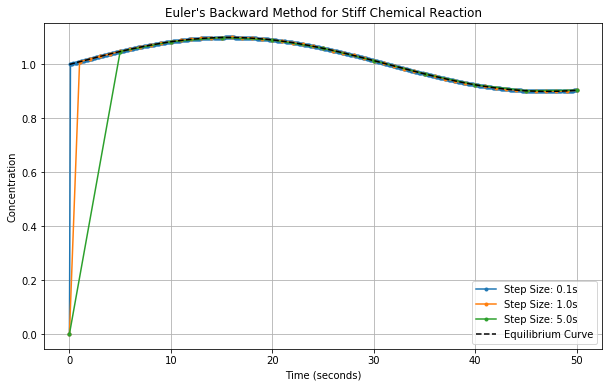

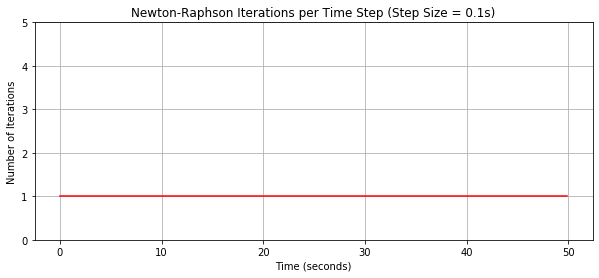

In [9]:
import matplotlib.pyplot as plt
import numpy as np

stepSizesToTest = [0.1, 1.0, 5.0]
totalSimTime = 50.0

plt.figure(figsize=(10, 6))

for currentStepSize in stepSizesToTest:
    timeData, concData, iterData = runEulersBackward(currentStepSize, totalSimTime)
    plt.plot(timeData, concData, label=f"Step Size: {currentStepSize}s", marker='o', markersize=3)

exactTime = np.linspace(0, totalSimTime, 1000)
exactEq = 1 + 0.1 * np.sin(0.1 * exactTime)
plt.plot(exactTime, exactEq, label="Equilibrium Curve", linestyle='--', color='black')

plt.title("Euler's Backward Method for Stiff Chemical Reaction")
plt.xlabel("Time (seconds)")
plt.ylabel("Concentration")
plt.legend()
plt.grid(True)
plt.show()

timeData, concData, iterData = runEulersBackward(0.1, totalSimTime)

plt.figure(figsize=(10, 4))
plt.plot(timeData[:-1], iterData, label="NR Iterations", color='red')
plt.title("Newton-Raphson Iterations per Time Step (Step Size = 0.1s)")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Iterations")
plt.ylim(0, 5)
plt.grid(True)
plt.show()

The most important thing I found is that Euler's Backward is incredibly stable. If you remember from Section 2, Euler's Forward completely blew up and gave me negative a million when I tried a step size of 0.1. But with Euler's Backward, a step size of 0.1 works perfectly! It jumps from 0 up to the equilibrium line almost instantly and then traces the sine wave smoothly.

Even more impressive, I pushed the step size up to 1.0 and 5.0 seconds. Explicit methods would fail instantly here, but Euler's Backward did not crash. The concentration values never exploded to infinity or went negative. They stayed bounded and hovered around the equilibrium line.

While the larger step sizes are mathematically stable, the graph shows they aren't very accurate. With a step size of 5.0 seconds, the points are so spaced out that the plot looks like a chunky, straight-line zig-zag instead of a smooth curve. It technically follows the general trend of the equilibrium, but it misses a lot of the actual wave shape. The 0.1 step size is the best of both worlds: it is entirely stable, and it takes enough snapshots to accurately draw the slow-moving target.

Looking at my second plot for the Newton-Raphson iterations, the graph is just a perfectly flat line sitting at 1 on the y-axis. This means the solver only needed exactly 1 loop to hit the tolerance level every single time it took a step.

This happened because my specific chemical reaction ODE is a linear equation. When you take the derivative of a linear equation, you just get a constant number. The Newton-Raphson method uses this derivative to correct its guess. For linear problems, the "correction slope" points directly at the exact right answer immediately, so it solves the implicit equation in just a single try. If I had picked a non-linear problem, I would likely see this taking 3 or 4 loops per step, but for this specific setup, it is super efficient.

# Section 6

To really understand why implicit methods are so important, I broke down the computational cost of both methods. I wanted to see exactly how much work the computer has to do to simulate 50 seconds of this chemical reaction.Here is a table comparing the two methods based on the data I gathered in the previous sections:


| Metric | Euler's Forward (Explicit) | Euler's Backward (Implicit) |
| :--- | :--- | :--- |
| **Max Stable Step Size** | 0.0002 seconds | Any size (Stable at 5.0+ seconds) |
| **Chosen Step Size** | 0.0001 seconds (to be safe) | 0.1 seconds (for good accuracy) |
| **Total Steps for 50s Sim** | 500,000 steps | 500 steps |
| **NR Iterations per Step** | None | 1 iteration (since it is linear) |
| **Total Function Calls** | 500,000 | 500 |

- Looking at the table, the difference is huge. Because Euler's Forward is restricted by that tiny stability limit, it is forced to take half a million steps just to simulate 50 seconds. That means evaluating the ODE function 500,000 times.On the other hand, Euler's Backward is unconditionally stable. By choosing a step size of 0.1 seconds, I only had to run 500 steps. Even though Euler's Backward requires a little extra math at each step because of the Newton-Raphson solver, our specific problem is linear so the solver only takes 1 loop per step. This means Euler's Backward finishes the job with about 1000 times less work.

- Even though Euler's Backward is stable at huge step sizes like 5.0 seconds, there is a catch. If you take steps that are too big, you gain a lot of computational efficiency, but you lose a lot of accuracy. A 5.0 second step size only takes 10 steps to finish the simulation, which is blazing fast, but as we saw in the Section 5 graph, it completely fails to capture the smooth curves of the sine wave equilibrium. It just draws clunky straight lines.If you make the step size smaller, like 0.1 seconds, you lose some efficiency because the computer has to do more steps, but you gain a ton of accuracy. The curve looks perfect.

- Based on my analysis, my main recommendation is to always use an implicit method like Euler's Backward when dealing with a stiff ODE. Explicit methods are just a waste of computing power for these types of problems.When picking a step size for Euler's Backward, my recommendation is to ignore the fast-moving part of the equation entirely (the 0.0001 second chemical reaction) and pick a step size that is just small enough to accurately draw the slow-moving part of the equation (the 10 second sine wave). A step size of 0.1 seconds gives plenty of data points to draw a smooth wave without overloading the computer.

# Section 7

Summary of Key Findings
- In this project, I found that my chemical reaction ODE had a massive stiffness ratio of 100,000. Because of this, the explicit Euler's Forward method completely failed and gave impossible numbers at a normal step size. However, the implicit Euler's Backward method stayed perfectly stable at that same step size and even at much larger ones.

When to Use Implicit vs. Explicit Methods
- I learned that explicit methods are fine for simple problems where everything happens at the same speed. But when dealing with stiff problems that have both fast and slow parts, you absolutely must use an implicit method so the numbers do not explode.

Challenges Encountered and Lessons Learned
- The biggest challenge for me was understanding why Euler's Forward crashed so violently in my first test. This taught me that just because a math formula is correct does not mean the computer can run it without strict limits. I also learned that a stable method can still draw bad graphs if the step size is too big, so finding the right balance is key.